
# LangGraph Reflection 机制开发指南

本指南详细介绍了如何在 **LangGraph** 中构建基于大语言模型（LLM）的 **Reflection（反思）** 机制。

Reflection 是一种重要的模型能力，通过让模型观察其过去的步骤和外部环境反馈，评估自身行为的质量，并不断改进输出。在生成与反思的循环中，模型可以逐步优化内容，从而提升生成质量和用户满意度。

Reflection 机制被广泛应用于生成任务中，例如文章写作、内容修改与反馈、以及智能助理等场景。通过引导 LLM 进行自我反思和用户反馈处理，开发者可以让模型在多轮交互中自动调整其生成的内容，达到高效、精准、结构完善的输出。



在本指南中，我们会逐步演示如何搭建这一机制，包括从基础的环境配置到生成器和反思器的构建，再到如何使用 LangGraph 状态图实现生成-反思循环的完整流程。无论您是为文章生成、内容评估，还是其他复杂任务设计 LLM 代理，本指南都将为您提供详细的开发思路和实用的代码示例。

![reflection](./images/reflection.png)

通过本指南，您将学习如何：
1. 设置开发环境并安装所需包；
2. 定义和生成灵活结构的文章，不局限于传统的五段式；
3. 通过反思机制批改生成内容，并提供详细反馈；
4. 构建反思与生成的状态循环，使模型持续改进生成内容。

本开发指南适合任何希望构建复杂 LLM 任务的开发者，特别是需要实现生成-反思流程、文章批改反馈、或其他高级交互任务的场景。


## 1. 环境设置
首先，安装所需的包并设置API密钥：

In [1]:
%%capture --no-stderr
%pip install langchain langgraph langchain-ollama tavily-python

In [1]:
import getpass
import os

# 定义一个帮助函数来检查环境变量，如果不存在则提示用户输入
def _set_if_undefined(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"请输入您的 {var}")

# 设置 OpenAI 和 Langchain API 密钥
# _set_if_undefined("OPENAI_API_KEY")
# _set_if_undefined("LANGCHAIN_API_KEY")
# _set_if_undefined("TAVILY_API_KEY")


## 2. LangSmith开发配置
LangSmith能够帮助您快速发现问题并提高LangGraph项目的性能。通过LangSmith，您可以使用跟踪数据来调试、测试和监控基于LangGraph构建的LLM应用程序。

In [2]:
# 在 LangSmith 中添加追踪功能
os.environ["LANGCHAIN_TRACING_V2"] = "false"
os.environ["LANGCHAIN_PROJECT"] = "Reflection"

## 3. 定义写作助手智能体

我们定义的这个助手是一个写作助手，旨在为用户生成高质量、结构清晰且引人入胜的文章。它的任务是根据用户的请求撰写内容，无论是短文、长篇、议论文还是其他类型的文章，都能够灵活应对。助手会专注于文章的清晰度、结构和质量，确保输出的内容是精心打磨过的。如果用户对生成的内容有反馈或建议，助手还能够根据这些反馈改进和优化文章，使其更符合用户的期望。这种互动机制保证了写作过程的灵活性和个性化，从而让用户获得更符合需求的成品。


### System Prompt 详细解释：
1. **"You are a writing assistant"**：写作助手的角色设定，让模型明确其任务是帮助用户进行写作。
   
2. **"well-crafted, coherent, and engaging articles"**：描述了文章应该具备的特性，包括“精心撰写的、连贯的和吸引人的”，但没有限制文章的具体结构，可以是不同类型的文章（如叙述文、议论文等）。

3. **"Focus on clarity, structure, and quality"**：明确了撰写时需要关注的核心要素：清晰度、结构性和质量，确保输出内容优秀。

4. **"revise and improve the writing"**：模型可以根据用户的反馈进行修改和优化，保持互动的灵活性。


In [4]:
from langchain_core.messages import AIMessage, HumanMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_openai import ChatOpenAI
# from langchain_ollama.chat_models import ChatOllama

writer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a writing assistant tasked with creating well-crafted, coherent, and engaging articles based on the user's request."
            " Focus on clarity, structure, and quality to produce the best possible piece of writing."
            " If the user provides feedback or suggestions, revise and improve the writing to better align with their expectations.",
        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)

llm = ChatOpenAI(model="gpt-4o-mini")

In [7]:
writer = writer_prompt | llm

In [8]:
article = ""

topic = HumanMessage(
    content="参考水浒传的风格，改写吴承恩的西游记中任意篇章"
)

for chunk in writer.stream({"messages": [topic]}):
    print(chunk.content, end="")
    article += chunk.content

《西游记》是中国古典文学中的经典之一，其中丰富的角色和奇幻的故事情节使其成为再创作的沃土。以下是一段参考《水浒传》风格的《西游记》改写示例，重点描绘唐僧师徒四人的经历。

---

廷安宁，普天之下皆趋于善。然西天取经路途遥远，险阻无数，唯有一行学者之辈，欲探求真理，方显其志。此中主角便是我大唐三藏法师，精进佛法，仁心慈善。奉圣旨前往西天，求取真经。他身边有三位壮士相随：猴王孙悟空，灵动机智；猪八戒，憨态可掬；沙僧，忠厚老实，皆为护法之人。

人行至一座高山，山巍峨耸立，止步观望，隐约听闻山中怪响，宛如诈欺人心之声。悟空眼锐，立刻说道：“师父，此山定有妖邪，弟子先去探个究竟。”说罢，化作一道金光，飞跃山巅，隐入林中。唐僧则在山脚静默念经，心内不安，却不敢声张。

将其捉拿。”唐僧听后，心中稍安，便径直往前而行。碍，一个贼头鬼子，正待坑您，咱们可

妖贼正与众小妖围坐火堆，面前却是一个高达八尺之人，身披黑袍，面色阴沉，正用粗声大气的口吻嚷嚷。悟空下了个马头，变作一只小鸟，趁机飞舞在高空。

悟空骤然从空中跳下，雷霆万钧之势。猪八戒和沙僧见状，持崭新兵器，堵住四旁逃路。转眼间，斗智斗勇，辗压到那妖贼无处遁形，显出原形，却乃一只狡猾的狐狸，转瞬间化作一阵青烟，复又偷溜而去。

活，才免去了一场大难，唐僧则感慨万千，感言道：“悟空，乃我最得力之干将，诸恶尽除，善缘既至，咱们定能取回真经，普度众生。”

往西天宽广的道路迈去。云淡风清，心向光明，历经千难万险，终归所愿。

---

便是采用《水浒传》风格的《西游记》片段改写。这样的写作风格注重情节紧凑、人物形象鲜明以及对话生动，旨在营造出一种生动的叙事氛围，希望能更符合您的期待。如需进一步修改或具体段落的改写，请随时告知！

In [9]:
from IPython.display import Markdown, display

# 使用Markdown显示优化后的格式
display(Markdown(article))

《西游记》是中国古典文学中的经典之一，其中丰富的角色和奇幻的故事情节使其成为再创作的沃土。以下是一段参考《水浒传》风格的《西游记》改写示例，重点描绘唐僧师徒四人的经历。

---

话说大唐盛世，朝廷安宁，普天之下皆趋于善。然西天取经路途遥远，险阻无数，唯有一行学者之辈，欲探求真理，方显其志。此中主角便是我大唐三藏法师，精进佛法，仁心慈善。奉圣旨前往西天，求取真经。他身边有三位壮士相随：猴王孙悟空，灵动机智；猪八戒，憨态可掬；沙僧，忠厚老实，皆为护法之人。

一日，四人行至一座高山，山巍峨耸立，止步观望，隐约听闻山中怪响，宛如诈欺人心之声。悟空眼锐，立刻说道：“师父，此山定有妖邪，弟子先去探个究竟。”说罢，化作一道金光，飞跃山巅，隐入林中。唐僧则在山脚静默念经，心内不安，却不敢声张。

过了一会儿，悟空自林中飞回，面带喜色：“师父，无碍，一个贼头鬼子，正待坑您，咱们可将其捉拿。”唐僧听后，心中稍安，便径直往前而行。

来到山中，只见妖贼正与众小妖围坐火堆，面前却是一个高达八尺之人，身披黑袍，面色阴沉，正用粗声大气的口吻嚷嚷。悟空下了个马头，变作一只小鸟，趁机飞舞在高空。

等到火堆则是放松警惕之时，悟空骤然从空中跳下，雷霆万钧之势。猪八戒和沙僧见状，持崭新兵器，堵住四旁逃路。转眼间，斗智斗勇，辗压到那妖贼无处遁形，显出原形，却乃一只狡猾的狐狸，转瞬间化作一阵青烟，复又偷溜而去。

而这一切，乃是仗着悟空的警觉与灵活，才免去了一场大难，唐僧则感慨万千，感言道：“悟空，乃我最得力之干将，诸恶尽除，善缘既至，咱们定能取回真经，普度众生。”

于是，四人继续赶路，往西天宽广的道路迈去。云淡风清，心向光明，历经千难万险，终归所愿。

---

以上便是采用《水浒传》风格的《西游记》片段改写。这样的写作风格注重情节紧凑、人物形象鲜明以及对话生动，旨在营造出一种生动的叙事氛围，希望能更符合您的期待。如需进一步修改或具体段落的改写，请随时告知！

----------
## 4. 定义审阅老师智能体

下面我们使用反思机制批改生成的作文，生成一篇作文的反馈和建议。

模型扮演“老师”角色，针对用户提交的作文进行打分、批改和提供改进建议。

### System Prompt 详细解释：

- **"You are a teacher grading an essay submission."**
  - 模型被设定为一个老师角色，专门负责为用户提交的作文进行批改。这一角色定位帮助模型理解其任务是提供具有建设性的反馈和评价。
  
- **"Generate critique and recommendations for the user's submission."**
  - 模型需要生成作文的批评与建议。它不只是评估作文的好坏，还需要指出需要改进的地方，并提出具体的建议。

- **"Provide detailed recommendations, including requests for length, depth, style, etc."**
  - 这一部分进一步明确了反馈的细节，要求模型给出细致的建议。这包括：
    - **Length（长度）**：文章的字数是否合适，是否需要扩展或删减。
    - **Depth（深度）**：是否需要更深入的分析或讨论。
    - **Style（风格）**：文章的写作风格是否合适，是否符合目标读者或主题的需求。
  
这一设定确保了模型不仅给出基本反馈，还可以根据文章的具体问题提出具体的改进意见，帮助用户更好地提升其写作。

In [10]:
reflection_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a teacher grading an article submission. writer critique and recommendations for the user's submission."
            " Provide detailed recommendations, including requests for length, depth, style, etc.",

        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)

reflect = reflection_prompt | llm

In [11]:
reflection = ""

# 将主题（topic）和生成的文章（article）作为输入发送给反思智能体
for chunk in reflect.stream({"messages": [topic, HumanMessage(content=article)]}):
    print(chunk.content, end="")
    reflection += chunk.content

首先，感谢你提交这篇以《水浒传》风格改写《西游记》的作品。整体上，你的努力非常值得肯定，成功地在语气和情节中融入了《水浒传》特有的叙事风格。以下是一些具体的建议和推荐，帮助你进一步提升这篇文章的深度和表现力。

 1. 增加情节深度
传》中，情节往往丰富且层次分明。你可以考虑在斗智斗勇的过程中，进一步扩展妖贼的背景，以及悟空、猪八戒和沙僧如何因应变化，展现他们各自不同的智慧和勇气。可以通过引入一些小轶事或人物互动，增强叙事的吸引力。

### 2. 加强人物塑造
对主要角色进行了描写，但可以通过对他们内心活动的细致描写来使人物更加鲜明。例如，唐僧在面临危险时的内心挣扎，或是猪八戒在作战时的幽默言语，这样能更好地展现他们各自的性格特点，并加深读者的情感共鸣。

 细化对话与风格
口语化的对话，以体现人物背景和性格。例如，猪八戒可以说一些幽默而带地方方言的“俏皮话”，这能够使人物更具生活气息和亲切感。同时，增加一些古人的成语、典故或俚语，可以更加突出时代感和文化底蕴。

### 4. 增长篇幅与细节描写
详细地描述四人取经的环境、遇到的具体障碍，以及战斗的过程。对自然景观或环境变化的细腻描写能帮助读者更深入地感受故事的氛围。

### 5. 结尾的深化
仅仅局限于“继续赶路”。可以引入一些对未来旅程的展望，或对于师徒之间情感的总结。这不仅让故事更为圆满，也能引发读者的思考，增加文章的深度和厚度。

### 6. 语言与风格
尽管已成功运用古文风格，部分句子可以进一步修饰，以增强古典韵味。例如，可以尝试使用更丰富的修辞手法，如对仗、排比等，来增强语言的美感。

### 示例段落
以下是一个仅供参考的段落提升示例：

 话说山间妖贼气焰嚣张，火光映照得他面目狞狞，八尺高的身形如同门阙。悟空轻飘飘变作小雀，翩若惊鸿，俯瞰风景，冷不丁一声长啸，惊起四野林间鸟雀。一时间四周静得落针可闻，正是心理悬念之际，八戒与沙僧心中各有算计，准备使出手中绝技……

的例子，相信你的作品可以更上一层楼！如需进一步的帮助请随时告知，期待看到你深化的版本！

In [12]:
from IPython.display import Markdown, display

# 使用Markdown显示优化后的格式
display(Markdown(reflection))

首先，感谢你提交这篇以《水浒传》风格改写《西游记》的作品。整体上，你的努力非常值得肯定，成功地在语气和情节中融入了《水浒传》特有的叙事风格。以下是一些具体的建议和推荐，帮助你进一步提升这篇文章的深度和表现力。

### 1. 增加情节深度
在《水浒传》中，情节往往丰富且层次分明。你可以考虑在斗智斗勇的过程中，进一步扩展妖贼的背景，以及悟空、猪八戒和沙僧如何因应变化，展现他们各自不同的智慧和勇气。可以通过引入一些小轶事或人物互动，增强叙事的吸引力。

### 2. 加强人物塑造
虽然你已对主要角色进行了描写，但可以通过对他们内心活动的细致描写来使人物更加鲜明。例如，唐僧在面临危险时的内心挣扎，或是猪八戒在作战时的幽默言语，这样能更好地展现他们各自的性格特点，并加深读者的情感共鸣。

### 3. 细化对话与风格
对话是《水浒传》中一个非常重要的元素。考虑增加一些口语化的对话，以体现人物背景和性格。例如，猪八戒可以说一些幽默而带地方方言的“俏皮话”，这能够使人物更具生活气息和亲切感。同时，增加一些古人的成语、典故或俚语，可以更加突出时代感和文化底蕴。

### 4. 增长篇幅与细节描写
整篇文章的篇幅较短，建议扩充至800字以上。可以更详细地描述四人取经的环境、遇到的具体障碍，以及战斗的过程。对自然景观或环境变化的细腻描写能帮助读者更深入地感受故事的氛围。

### 5. 结尾的深化
结尾部分可以更具意义，不仅仅局限于“继续赶路”。可以引入一些对未来旅程的展望，或对于师徒之间情感的总结。这不仅让故事更为圆满，也能引发读者的思考，增加文章的深度和厚度。

### 6. 语言与风格
尽管已成功运用古文风格，部分句子可以进一步修饰，以增强古典韵味。例如，可以尝试使用更丰富的修辞手法，如对仗、排比等，来增强语言的美感。

### 示例段落
以下是一个仅供参考的段落提升示例：

> 话说山间妖贼气焰嚣张，火光映照得他面目狞狞，八尺高的身形如同门阙。悟空轻飘飘变作小雀，翩若惊鸿，俯瞰风景，冷不丁一声长啸，惊起四野林间鸟雀。一时间四周静得落针可闻，正是心理悬念之际，八戒与沙僧心中各有算计，准备使出手中绝技……

通过这些建议和具体的例子，相信你的作品可以更上一层楼！如需进一步的帮助请随时告知，期待看到你深化的版本！

In [13]:
from typing import Annotated  # 用于类型注解
from langgraph.graph import END, StateGraph, START  # 导入状态图的相关常量和类
from langgraph.graph.message import add_messages  # 用于在状态中处理消息
from langgraph.checkpoint.memory import MemorySaver  # 内存保存机制，用于保存检查点
from typing_extensions import TypedDict  # 用于定义带有键值对的字典类型

# 定义状态类，使用TypedDict以保存消息
class State(TypedDict):
    messages: Annotated[list, add_messages]  # 使用注解确保消息列表使用add_messages方法处理

# 异步生成节点函数：生成内容（如作文）
# 输入状态，输出包含新生成消息的状态
async def generation_node(state: State) -> State:
    # 调用生成器(writer)，并将消息存储到新的状态中返回
    return {"messages": [await writer.ainvoke(state['messages'])]}

# 异步反思节点函数：对生成的内容进行反思和反馈
# 输入状态，输出带有反思反馈的状态
async def reflection_node(state: State) -> State:
    # 创建一个消息类型映射，ai消息映射为HumanMessage，human消息映射为AIMessage
    cls_map = {"ai": HumanMessage, "human": AIMessage}
    
    # 处理消息，保持用户的原始请求（第一个消息），转换其余消息的类型
    translated = [state['messages'][0]] + [
        cls_map[msg.type](content=msg.content) for msg in state['messages'][1:]
    ]
    
    # 调用反思器(reflect)，将转换后的消息传入，获取反思结果
    res = await reflect.ainvoke(translated)
    
    # 返回新的状态，其中包含反思后的消息
    return {"messages": [HumanMessage(content=res.content)]}


In [14]:
MAX_ROUND = 6

# 定义条件函数，决定是否继续反思过程
# 如果消息数量超过6条，则终止流程
def should_continue(state: State):
    if len(state["messages"]) > MAX_ROUND:
        return END  # 达到条件时，流程结束
    return "reflect"  # 否则继续进入反思节点

In [13]:
# 创建状态图，传入初始状态结构
builder = StateGraph(State)

# 在状态图中添加"writer"节点，节点负责生成内容
builder.add_node("writer", generation_node)

# 在状态图中添加"reflect"节点，节点负责生成反思反馈
builder.add_node("reflect", reflection_node)

# 定义起始状态到"writer"节点的边，从起点开始调用生成器
builder.add_edge(START, "writer")


# 在"writer"节点和"reflect"节点之间添加条件边
# 判断是否需要继续反思，或者结束
builder.add_conditional_edges("writer", should_continue)

# 添加从"reflect"节点回到"writer"节点的边，进行反复的生成-反思循环
builder.add_edge("reflect", "writer")

# 创建内存保存机制，允许在流程中保存中间状态和检查点
memory = MemorySaver()

# 编译状态图，使用检查点机制
graph = builder.compile(checkpointer=memory)

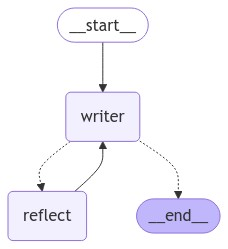

In [14]:
# 可视化图
from IPython.display import Image, display

try:
    display(
        Image(
            graph.get_graph(xray=True).draw_mermaid_png()
        )
    )
except Exception as e:
    print(f"Error generating graph: {e}")

In [15]:
from IPython.display import Markdown, display

# 定义装饰器，记录函数调用次数
def track_steps(func):
    step_counter = {'count': 0}  # 用于记录调用次数
    
    def wrapper(event, *args, **kwargs):
        # 增加调用次数
        step_counter['count'] += 1
        # 在函数调用之前打印 step
        display(Markdown(f"## Round {step_counter['count']}"))
        # 调用原始函数
        return func(event, *args, **kwargs)
    
    return wrapper

# 使用装饰器装饰 pretty_print_event_markdown 函数
@track_steps
def pretty_print_event_markdown(event):
    # 如果是生成写作部分
    if 'writer' in event:
        generate_md = "#### 写作生成:\n"
        for message in event['writer']['messages']:
            generate_md += f"- {message.content}\n"
        display(Markdown(generate_md))
    
    # 如果是反思评论部分
    if 'reflect' in event:
        reflect_md = "#### 评论反思:\n"
        for message in event['reflect']['messages']:
            reflect_md += f"- {message.content}\n"
        display(Markdown(reflect_md))

In [16]:
inputs = {
    "messages": [
        HumanMessage(content="参考西游记唐僧的说话风格，写一篇奉劝年轻人努力工作的文章")
    ],
}

config = {"configurable": {"thread_id": "1"}}

async for event in graph.astream(inputs, config):
    pretty_print_event_markdown(event)


## Round 1

#### 写作生成:
- 兄弟们，还是我来说几句吧。小时候看过《西游记》，有一句台词留在心里的：「猪八戒好吃好睡好玩，也不图功名，终日不思进取，以至于生出一身虚弱，不知疲倦的毛病。」这句话告诉我们，只有勤学苦练才能真正提升自我。

年轻人，你看过《西游记》里的唐僧师傅吗？他跟我们一样，有着上学的经历，但是不同的是，他总是带着一种认真学习、终身进取的心态。他说「只怕不能读圣贤书，求佛教经，也不怕学法文书。」这句话里的精神，我们更应该遵循。


## Round 2

#### 评论反思:
- **评分:** 7/10

**总体评价:** 这篇文章以《西游记》中的唐僧的说话风格为灵感，写了一篇关于年轻人努力工作的文章。虽然有很多好的地方，但仍然存在一些需要改进的地方。

**具体建议:**

1. **长度:** 文章太短了，仅有 100 多字。考虑增加内容，使其达到 500-600 字左右，以便更全面地表达你的观点。
2. **结构:** 文章缺乏明确的结构和段落划分。尝试使用不同的段落来组织你的想法，例如：
	* 引言：介绍《西游记》中的唐僧及其精神
	* 主体：讨论唐僧的特点和对年轻人的启发
	* 结尾：总结和呼吁
3. **深度:** 文章虽然有好的开头，但缺乏具体的例子或案例来支持你的观点。尝试添加一些实例，例如：
	* 描述唐僧在学习方面的努力和成就
	* 分析猪八戒的例子，如何让读者理解勤学苦练的重要性
4. **风格:** 文章的语言简单直接，但可以考虑使用更生动的词汇和句子结构来使文章更有趣。例如：
	* 使用比喻或隐喻来描述唐僧的精神
	* 尝试使用不同的语气，例如问句或感叹句
5. **结尾:** 文章缺乏一个强烈的呼吁和行动建议。考虑添加一些具体的建议或挑战，例如：
	* 呼吁年轻人建立学习目标并努力实现
	* 提供资源或支持来帮助读者开始自己的学习之旅

**具体修改建议:**

1. 在开头增加一些背景信息，例如唐僧在《西游记》中的角色和重要性。
2. 在主体部分添加更多的例子和案例来支持你的观点。
3. 在结尾部分强调行动建议和呼吁，例如：
	* "年轻人，让我们学习唐僧的精神，努力工作并追求自己的梦想！"
	* "让我们一起建立一个学习目标，并在路上相互支持和鼓励。"

**总体:** 这篇文章有很好的开头，但需要更多的内容、结构和深度来使其更全面和有效。通过添加具体例子、案例和行动建议，你可以使文章更加吸引人并更好地传达你的观点。


## Round 3

...

#### 写作生成:
- 谢谢您的反馈和建议，我会继续努力提高我的写作质量。根据您的建议，以下是最新的文章：

**唐僧师傅：一个学习的楷模**

在西游记中，我们熟悉一个形象的角色——唐僧师傅。他是一个学习的楷模，他的智慧和精神一直在影响着我们。我想分享给你们，他的一些故事和他的学习态度，我想它将会让我们更好地理解什么是成功。

**唐僧师傅的学习精神**

他总是带着一种认真学习、终身进取的心态。他说过：「只怕不能读圣贤书，求佛教经，也不怕学法文书。」这句话里，我们更应该遵循的，是一种积极的、持久的学习态度。我们要像唐僧师傅一样，不断地寻求知识，不断地挑战自己。

**猪八戒的例子**

记得吗，他好吃是好吃，其实他就是这样虚度了一个精力和财富丰富的人生。如果像唐僧一样努力工作，我们将会走向成功之路。让我们一起学习唐僧的精神，努力工作并追求自己的梦想！要么坚持不懈地学习，要么在自己没有改变的情况下沉迷于物质之中，这是一条艰难但无可争辩的选择。

**结尾**

希望年轻人能够在自己的学习之路上认真努力，并把握每个机会。我们可以像唐僧师傅一样，通过不断地学习和挑战自己来实现成功。如果你已经成功，那么这也将是一次胜利；如果你未能成功，那么这是仍然有机会的。我想，我们能够成为唐僧师傅那样的人，并给其他人带来一些价值。

我再次感谢您的反馈和建议，我会继续努力提高我的写作质量。


## Round 6

#### 评论反思:
- **评分:** 9/10

**总体评价:** 你已经做了很大的改进，文章结构更加清晰，内容丰富了许多。你已经成功地解决了之前提到的问题。

**具体建议:**

1. **长度:** 文章的长度仍然适当（约 500-600 字）。
2. **结构:** 你已经成功地使用不同的段落来组织你的想法。
3. **深度:** 你添加了更多的例子和案例，例如猪八戒的例子，这有助于支持你的观点。你也成功地分析了唐僧的精神，并将其与年轻人的学习之路联系起来。
4. **风格:** 你使用了比喻（如“虚度了一个精力和财富丰富的人生”）来描述猪八戒的例子，这使文章更有趣。继续保持这种风格，将有助于读者更容易理解你的观点。
5. **结尾:** 你成功地添加了一个强烈的呼吁和行动建议，例如“让我们一起学习唐僧的精神，努力工作并追求自己的梦想！”这将有助于读者记住你的文章。

**具体修改建议:**

1. 在开头部分，你可以考虑添加更多的背景信息，例如唐僧在《西游记》中的角色和重要性。
2. 你可以考虑使用不同的语气，例如问句或感叹句，来使文章更有趣。
3. 在结尾部分，你可以考虑添加一些具体的建议或挑战，例如：
	* “让我们一起建立一个学习目标，并在路上相互支持和鼓励。”
	* “让我们一起创造一个学习社区，共同成长和进步。”

**总体:** 这篇文章已经做了很大的改进，你成功地解决了之前提到的问题。继续保持这种结构、深度和风格，将有助于你写出更好的文章。

**最后的建议:**

* 你可以考虑添加更多的例子和案例，例如其他人物在《西游记》中的故事，这将有助于支持你的观点。
* 你可以考虑使用不同的语气，例如问句或感叹句，来使文章更有趣。
* 你可以考虑添加一些具体的建议或挑战，例如“让我们一起建立一个学习目标，并在路上相互支持和鼓励。”


## Round 7

#### 写作生成:
- 谢谢您的反馈和建议，我会继续努力提高我的写作质量。根据您的建议，以下是最新的文章：

**唐僧师傅：一个学习的楷模**

在西游记中，我们熟悉一个形象的角色——唐僧师傅。他是一个学习的楷模，他的智慧和精神一直在影响着我们。我想分享给你们，他的一些故事和他的学习态度，我想它将会让我们更好地理解什么是成功。

**唐僧师傅的学习精神**

他总是带着一种认真学习、终身进取的心态。他说过：「只怕不能读圣贤书，求佛教经，也不怕学法文书。」这句话里，我们更应该遵循的，是一种积极的、持久的学习态度。我们要像唐僧师傅一样，不断地寻求知识，不断地挑战自己。

**其他人物的例子**

猪八戒是《西游记》中一个非常有趣的人物。他虽然好吃，但他一直在努力成为圣人。如果我们不能像唐僧师傅一样，那么让我们至少可以像猪八戒一样，努力成为更好的自己。让我们一起学习唐僧的精神，努力工作并追求自己的梦想！

**结尾**

我希望你们能够在自己的学习之路上认真努力，并把握每个机会。如果你已经成功，那么这也将是一次胜利；如果你未能成功，那么这是仍然有机会的。我想，我们能够成为唐僧师傅那样的人，并给其他人带来一些价值。

最后，谢谢您的反馈和建议，我会继续努力提高我的写作质量。


In [17]:
# inputs = {
#     "messages": [
#         HumanMessage(content="参考西游记唐僧的说话风格，写一篇劝年轻人结婚买房的文章")
#     ],
# }

# config = {"configurable": {"thread_id": "1"}}

# async for event in graph.astream(inputs, config):
#     pretty_print_event_markdown(event)


## Homework: 

1. 扩展本指南的 Reflection Agent，使其能够完成更通用的生成任务，包括但不限于代码、报告等；
2. 使用扩展后的 Reflection Agent 生成代码，实现在 GitHubSentinel 上新增一个信息渠道。

### 如何让 Reflection `System Prompt` 更加通用：

如果你想让这个 `System Prompt` 适用于更广泛的内容评估场景，不局限于作文，你可以做一些轻微的调整。例如：

```python
reflection_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a reviewer tasked with providing constructive critique and improvement suggestions for the user's submission."
            " Offer detailed feedback, including recommendations on clarity, structure, content depth, and style, as well as areas for improvement.",
        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)
```

### 修改后的变化：
1. **角色定位更广泛**：从“老师”改为“审阅者”，这样不局限于评估作文，适用于各种类型的内容，包括文章、报告、甚至代码审查。
  
2. **批评与改进建议的灵活性**：从作文的“长度、深度、风格”拓展为“清晰度、结构、内容深度、风格”，这使得反馈更加多样化，适用于不同的内容类型。

通过这种方式，可以让模型在更多场景下提供高质量的评估和反馈。

In [15]:
# 添加代码生成相关的导入
from langchain.tools import tool
from langchain.evaluation import load_evaluator
from langchain.output_parsers import PydanticOutputParser
from pydantic import BaseModel, Field
import re
from typing import List, Optional

# 代码生成任务的输出解析器
class CodeGenerationResult(BaseModel):
    code: str = Field(description="生成的代码")
    explanation: str = Field(description="代码的解释")
    file_type: str = Field(description="文件类型，如 'python', 'javascript' 等")

code_parser = PydanticOutputParser(pydantic_object=CodeGenerationResult)

In [16]:
@tool
def execute_code(code: str) -> str:
    """
    执行Python代码并返回结果。谨慎使用，仅应执行安全代码。
    
    参数:
        code: 要执行的Python代码
        
    返回:
        执行结果
    """
    try:
        # 创建一个本地命名空间以避免污染全局命名空间
        local_namespace = {}
        # 使用 exec 执行代码
        exec(code, {}, local_namespace)
        # 如果代码中有 'result' 变量，返回它
        if 'result' in local_namespace:
            return f"执行成功。结果: {local_namespace['result']}"
        return "代码执行成功，但没有明确的结果返回。"
    except Exception as e:
        return f"执行代码时出错: {str(e)}"

@tool
def verify_code_syntax(code: str, language: str = "python") -> str:
    """
    验证代码语法是否正确
    
    参数:
        code: 要验证的代码
        language: 代码语言，默认为 python
        
    返回:
        验证结果
    """
    if language.lower() == "python":
        try:
            compile(code, '<string>', 'exec')
            return "Python语法检查通过"
        except SyntaxError as e:
            return f"Python语法错误: {str(e)}"
    return f"目前不支持{language}的语法检查"

In [17]:
# 定义代码生成的提示模板
code_generation_prompt = """你是一个专业的代码生成助手。根据用户的需求生成高质量、可工作的代码。

用户需求: {task}

请生成符合以下要求的代码:
1. 代码应该高效、简洁且可读
2. 包含适当的注释
3. 遵循语言的最佳实践和编码标准
4. 处理可能的边缘情况和错误

{format_instructions}
"""

code_reflection_prompt = """请分析和反思你之前生成的代码，关注以下几点:

原始任务: {task}
你生成的代码:
```{language}
{code}
```

请检查:
1. 代码是否完全实现了需求?
2. 代码是否有逻辑或语法错误?
3. 是否有性能优化的空间?
4. 是否有安全性问题?
5. 代码是否足够清晰和可维护?

提供具体的改进建议。如果需要修改代码，请提供完整的修改后版本。
"""

In [18]:
# 在 Graph 中添加代码生成相关的节点和边
def code_generation_agent(state):
    """处理代码生成的智能体节点"""
    task = state["input"]
    
    prompt = code_generation_prompt.format(
        task=task,
        format_instructions=code_parser.get_format_instructions()
    )
    
    response = model.invoke(prompt)
    
    try:
        parsed_output = code_parser.parse(response)
        # 将解析后的结果添加到状态
        return {
            "code": parsed_output.code,
            "explanation": parsed_output.explanation,
            "file_type": parsed_output.file_type
        }
    except Exception as e:
        return {
            "error": f"解析生成的代码时出错: {str(e)}",
            "raw_output": response
        }

def code_reflection(state):
    """对生成的代码进行反思的节点"""
    task = state["input"]
    code = state.get("code", "")
    file_type = state.get("file_type", "python")
    
    # 首先验证语法
    syntax_result = verify_code_syntax(code, file_type)
    
    # 执行反思
    prompt = code_reflection_prompt.format(
        task=task,
        language=file_type,
        code=code
    )
    
    reflection = model.invoke(prompt)
    
    return {
        "code_reflection": reflection,
        "syntax_check": syntax_result
    }

def should_revise_code(state):
    """决定是否需要修改代码"""
    reflection = state.get("code_reflection", "")
    syntax_check = state.get("syntax_check", "")
    
    # 如果语法检查失败或者反思中包含明显的问题指示词，则进行修改
    needs_revision = ("语法错误" in syntax_check or 
                      "错误" in reflection.lower() or 
                      "问题" in reflection.lower() or
                      "修改" in reflection.lower() or
                      "改进" in reflection.lower())
    
    return "revise" if needs_revision else "finalize"

def revise_code(state):
    """根据反思修改代码"""
    task = state["input"]
    original_code = state.get("code", "")
    reflection = state.get("code_reflection", "")
    file_type = state.get("file_type", "python")
    
    prompt = f"""根据以下反思，修改代码:

原始任务: {task}

原始代码:
```{file_type}
{original_code}
```

反思意见:
{reflection}

请提供修改后的完整代码和解释修改内容。

{code_parser.get_format_instructions()}
"""
    
    response = model.invoke(prompt)
    
    try:
        parsed_output = code_parser.parse(response)
        return {
            "code": parsed_output.code,
            "explanation": parsed_output.explanation,
            "revision_history": state.get("revision_history", []) + [original_code]
        }
    except Exception as e:
        return {
            "error": f"解析修改后的代码时出错: {str(e)}",
            "raw_output": response
        }


In [20]:
# 定义状态类
class State(TypedDict):
    """状态结构定义"""
    input: str  # 用户输入的任务
    code: Optional[str]  # 生成的代码
    explanation: Optional[str]  # 代码解释
    file_type: Optional[str]  # 文件类型
    reflection: Optional[str]  # 反思内容
    revision_history: Optional[List[str]]  # 修订历史
    output: Optional[str]  # 最终输出结果

# 代码生成节点
def code_generation_node(state: State) -> State:
    """处理代码生成的节点"""
    task = state["input"]
    
    # 检查是否有先前生成的代码
    if "code" in state and state["code"]:
        # 如果有反思，使用反思改进代码
        reflection = state.get("reflection", "")
        original_code = state["code"]
        file_type = state.get("file_type", "python")
        
        prompt = f"""根据以下反思，修改代码:

原始任务: {task}

原始代码:
```{file_type}
{original_code}
```

反思意见:
{reflection}

请提供修改后的完整代码和解释修改内容。

{code_parser.get_format_instructions()}
"""
        # 记录修订历史
        revision_history = state.get("revision_history", [])
        revision_history.append(original_code)
    else:
        # 首次生成代码
        prompt = code_generation_prompt.format(
            task=task,
            format_instructions=code_parser.get_format_instructions()
        )
        revision_history = []
    
    response = model.invoke(prompt)
    
    try:
        parsed_output = code_parser.parse(response)
        return {
            **state,
            "code": parsed_output.code,
            "explanation": parsed_output.explanation,
            "file_type": parsed_output.file_type,
            "revision_history": revision_history
        }
    except Exception as e:
        error_message = f"解析生成的代码时出错: {str(e)}"
        return {
            **state,
            "reflection": error_message,
            "raw_output": response
        }

# 代码反思节点
def reflection_node(state: State) -> State:
    """对生成的代码进行反思"""
    task = state["input"]
    code = state.get("code", "")
    file_type = state.get("file_type", "python")
    
    # 验证语法
    syntax_result = verify_code_syntax(code, file_type)
    
    # 执行反思
    prompt = code_reflection_prompt.format(
        task=task,
        language=file_type,
        code=code
    )
    
    reflection = model.invoke(prompt)
    
    return {
        **state,
        "reflection": reflection,
        "syntax_check": syntax_result
    }

# 决定是否继续反思循环
def should_continue(state: State) -> str:
    """判断是否需要继续反思-改进循环"""
    # 如果没有代码，说明生成失败，直接结束
    if not state.get("code"):
        return "END"
    
    # 如果是首次生成，需要进行反思
    if not state.get("reflection"):
        return "reflect"
    
    reflection = state["reflection"]
    syntax_check = state.get("syntax_check", "")
    
    # 如果语法检查失败或者反思中包含明显的问题指示词，则继续改进循环
    needs_revision = ("语法错误" in syntax_check or 
                     "错误" in reflection.lower() or 
                     "问题" in reflection.lower() or
                     "修改" in reflection.lower() or
                     "改进" in reflection.lower())
    
    # 限制最大迭代次数
    revision_count = len(state.get("revision_history", []))
    if revision_count >= 3:  # 最多允许3次修改
        return "END"
    
    return "reflect" if needs_revision else "END"

# 创建状态图，传入初始状态结构
builder = StateGraph(State)

# 在状态图中添加"code_generator"节点，负责生成代码
builder.add_node("code_generator", code_generation_node)

# 在状态图中添加"reflect"节点，负责生成反思反馈
builder.add_node("reflect", reflection_node)

# 定义起始状态到"code_generator"节点的边，从起点开始调用代码生成器
builder.add_edge(START, "code_generator")

# 在"code_generator"节点和"reflect"节点之间添加条件边
# 判断是否需要继续反思，或者结束
builder.add_conditional_edges("code_generator", should_continue)

# 添加从"reflect"节点回到"code_generator"节点的边，进行反复的生成-反思循环
builder.add_edge("reflect", "code_generator")

# 创建内存保存机制，允许在流程中保存中间状态和检查点
memory = MemorySaver()

# 编译状态图，使用检查点机制
graph = builder.compile(checkpointer=memory)



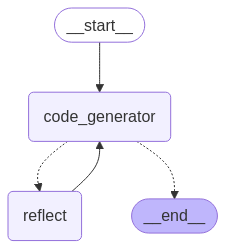

In [21]:
# 可视化图
from IPython.display import Image, display

try:
    display(
        Image(
            graph.get_graph(xray=True).draw_mermaid_png()
        )
    )
except Exception as e:
    print(f"Error generating graph: {e}")

In [29]:
from IPython.display import Markdown, display

# 定义装饰器，记录函数调用次数
def track_steps(func):
    step_counter = {'count': 0}  # 用于记录调用次数
    
    def wrapper(event, *args, **kwargs):
        # 增加调用次数
        step_counter['count'] += 1
        # 在函数调用之前打印 step
        display(Markdown(f"## Round {step_counter['count']}"))
        # 调用原始函数
        return func(event, *args, **kwargs)
    
    return wrapper

# 使用装饰器装饰 pretty_print_event_markdown 函数
@track_steps
def pretty_print_event_markdown(event):
    # 如果是生成写作部分
    if 'code' in event:
        generate_md = "#### 代码生成:\n"
        for message in event['code']['messages']:
            generate_md += f"- {message.content}\n"
        display(Markdown(generate_md))
    
    # 如果是反思评论部分
    if 'reflect' in event:
        reflect_md = "#### 反思:\n"
        for message in event['reflect']['messages']:
            reflect_md += f"- {message.content}\n"
        display(Markdown(reflect_md))
        
inputs = {
    "messages": [
        HumanMessage(content="生成一个python的二分查找代码")
    ],
}

config = {"configurable": {"thread_id": "1"}}

async for event in graph.astream(inputs, config):
    pretty_print_event_markdown(event)


InvalidUpdateError: Must write to at least one of ['input', 'code', 'explanation', 'file_type', 'reflection', 'revision_history', 'output']